In [1]:
from Configurations.imports import *
from Configurations.file_path import data_parent_path

In [2]:
file_route = data_parent_path / "height-weight.csv"

In [3]:
df = pd.read_csv(file_route)
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [8]:
# Step 1: Divide the dataset into dependent and independent feature
X = df[["Weight"]]
y = df[["Height"]]

In [9]:
# Step 2: Splitting the data into train and test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
# Checking the shape
x_train.shape, x_test.shape

((17, 1), (6, 1))

In [ ]:
#Step 3: Standardizing the  inputs
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [13]:
# Training the model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression(n_jobs=-1)

regressor.fit(x_train_scaled, y_train)
y_pred = regressor.predict(x_test_scaled)

In [16]:
print("the slope is: " , regressor.coef_)
print("the intercept is: ", regressor.intercept_)

the slope is:  [[17.2982057]]
the intercept is:  [156.47058824]


<Axes: >

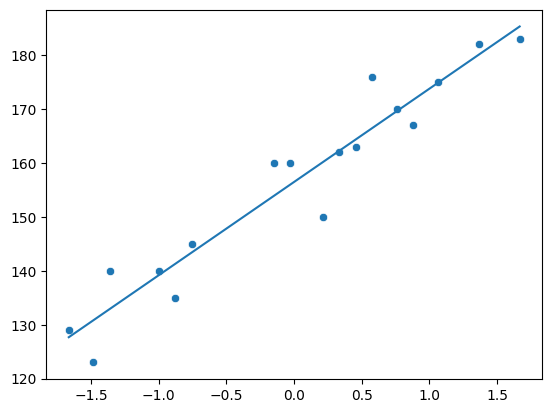

In [34]:
sns.scatterplot(x=x_train_scaled.flatten(), y=y_train.to_numpy().flatten())
sns.lineplot(x=x_train_scaled.flatten(), y=regressor.predict(x_train_scaled).flatten())

In [39]:
# Evaluate the model
from sklearn.metrics import r2_score, mean_squared_error
score = r2_score(y_test, y_pred) * 100
score

73.60826717981276

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("the average distance between the observed and actual output point is: ", rmse)

the average distance between the observed and actual output point is:  10.716374991212605


In [ ]:
# handling new point
scaled_weight = scaler.transform([[80]])
scaled_weight

c:\Users\Ameyu\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.45613165]])

In [45]:
regressor.predict(scaled_weight)

array([[164.36084726]])

#### Assumptions

<Axes: >

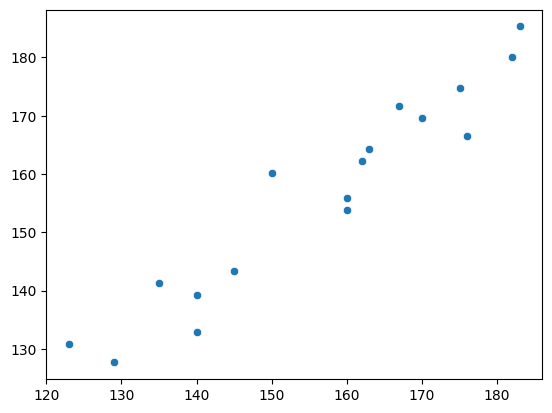

In [ ]:
sns.scatterplot(x=y_train.to_numpy().flatten(), y=regressor.predict(x_train_scaled).flatten())
# it is a linear relationship

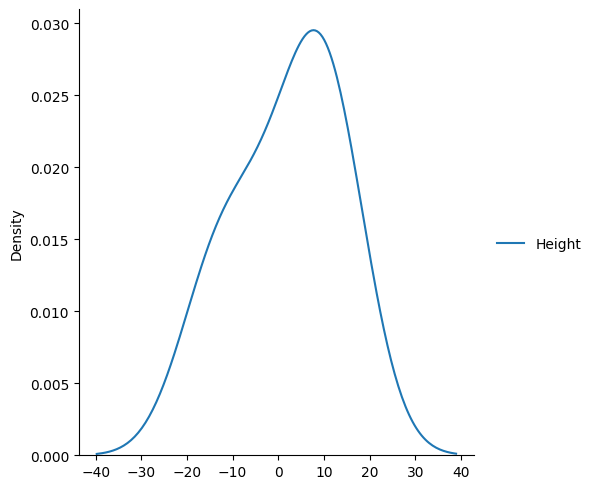

In [48]:
# residuals
diff = y_test - y_pred
sns.displot(data=diff, kind="kde")

<Axes: >

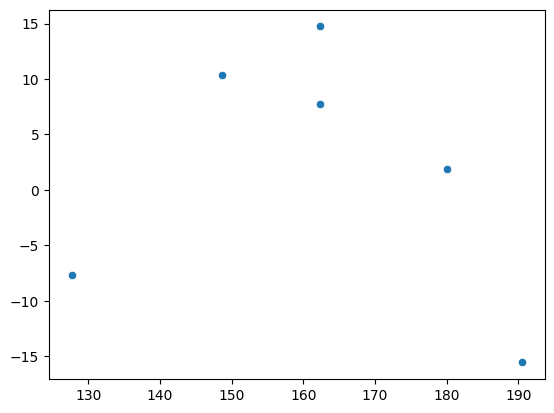

In [ ]:
# scatter plot between prediction and residuals
sns.scatterplot(x=y_pred.flatten(), y=diff.to_numpy().flatten())
# it is uniform distribution